# Women's Rankings

Get ratings of each team in a given year. This file needs to be ran for every relevant year (starting in 2008). 

### Data Setup

In [1]:
import pandas as pd

season = 2012

df = pd.read_parquet(fr'..\data\unprocessed\womens_sports_reference\full_season_sports_reference_{season}.parquet')

# only include games before NCAA tournament
df = df.loc[df['NCAA Tournament'] == 0, :].reset_index(drop=True)

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Opponent TOV,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo
0,Air Force,2011-11-11,0,-1,Lipscomb,REG (Non-Conf),1,68.0,59.0,23.0,...,23.0,24.0,0,0,9.0,1.361013,77.42,0.878326,0.762077,77.420000
1,Air Force,2011-11-13,0,-1,Tennessee-Martin,REG (Non-Conf),-1,60.0,84.0,27.0,...,18.0,7.0,0,0,-24.0,1.500000,81.80,0.733496,1.026895,81.800000
2,Air Force,2011-11-17,0,1,Denver,REG (Non-Conf),-1,52.0,54.0,20.0,...,20.0,19.0,0,0,-2.0,1.102120,78.00,0.666667,0.692308,78.000000
3,Air Force,2011-11-19,0,-1,Texas Southern,REG (Non-Conf),1,64.0,54.0,20.0,...,30.0,27.0,0,0,10.0,1.381279,80.54,0.794636,0.670474,80.540000
4,Air Force,2011-11-21,0,-1,Texas State,REG (Non-Conf),1,77.0,69.0,25.0,...,14.0,20.0,0,0,8.0,1.338710,77.22,0.997151,0.893551,77.220000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,Youngstown State,2012-02-18,0,1,Green Bay,REG (Conf),-1,72.0,77.0,21.0,...,14.0,19.0,1,1,-5.0,1.253292,73.40,0.980926,1.049046,65.244444
10252,Youngstown State,2012-02-23,0,-1,Wright State,REG (Conf),-1,62.0,84.0,21.0,...,10.0,15.0,0,0,-22.0,1.500000,73.98,0.838064,1.135442,73.980000
10253,Youngstown State,2012-02-25,0,-1,Detroit Mercy,REG (Conf),-1,64.0,67.0,20.0,...,10.0,14.0,0,0,-3.0,1.166625,62.76,1.019758,1.067559,62.760000
10254,Youngstown State,2012-03-03,0,-1,Cleveland State,REG (Conf),-1,69.0,79.0,24.0,...,24.0,22.0,0,0,-10.0,1.381279,86.84,0.794565,0.909719,86.840000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10256 entries, 0 to 10255
Data columns (total 59 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Team                         10256 non-null  object        
 1   Date                         10256 non-null  datetime64[ns]
 2   NCAA Tournament              10256 non-null  int32         
 3   Location                     10256 non-null  int8          
 4   Opponent                     10256 non-null  object        
 5   Type                         10256 non-null  object        
 6   Result                       10256 non-null  int8          
 7   Team Score                   10256 non-null  float64       
 8   Opponent Score               10256 non-null  float64       
 9   Team FG                      10256 non-null  float64       
 10  Team FGA                     10256 non-null  float64       
 11  Team FG%                     10256 non-nu

Create recency bias

In [3]:
# games at the beginning of the season should be about 0.8, games at the end will be 1.2

df['Recency Bias'] = 0.996018**(df['Date'].max() - df['Date']).dt.days + 0.2

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Opponent PF,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias
0,Air Force,2011-11-11,0,-1,Lipscomb,REG (Non-Conf),1,68.0,59.0,23.0,...,24.0,0,0,9.0,1.361013,77.42,0.878326,0.762077,77.420000,0.804875
1,Air Force,2011-11-13,0,-1,Tennessee-Martin,REG (Non-Conf),-1,60.0,84.0,27.0,...,7.0,0,0,-24.0,1.500000,81.80,0.733496,1.026895,81.800000,0.809721
2,Air Force,2011-11-17,0,1,Denver,REG (Non-Conf),-1,52.0,54.0,20.0,...,19.0,0,0,-2.0,1.102120,78.00,0.666667,0.692308,78.000000,0.819530
3,Air Force,2011-11-19,0,-1,Texas Southern,REG (Non-Conf),1,64.0,54.0,20.0,...,27.0,0,0,10.0,1.381279,80.54,0.794636,0.670474,80.540000,0.824494
4,Air Force,2011-11-21,0,-1,Texas State,REG (Non-Conf),1,77.0,69.0,25.0,...,20.0,0,0,8.0,1.338710,77.22,0.997151,0.893551,77.220000,0.829497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,Youngstown State,2012-02-18,0,1,Green Bay,REG (Conf),-1,72.0,77.0,21.0,...,19.0,1,1,-5.0,1.253292,73.40,0.980926,1.049046,65.244444,1.097871
10252,Youngstown State,2012-02-23,0,-1,Wright State,REG (Conf),-1,62.0,84.0,21.0,...,15.0,0,0,-22.0,1.500000,73.98,0.838064,1.135442,73.980000,1.115963
10253,Youngstown State,2012-02-25,0,-1,Detroit Mercy,REG (Conf),-1,64.0,67.0,20.0,...,14.0,0,0,-3.0,1.166625,62.76,1.019758,1.067559,62.760000,1.123302
10254,Youngstown State,2012-03-03,0,-1,Cleveland State,REG (Conf),-1,69.0,79.0,24.0,...,22.0,0,0,-10.0,1.381279,86.84,0.794565,0.909719,86.840000,1.149453


### Model Building

##### Team Ratings

In [4]:
X = (
    pd.get_dummies(df['Team']).astype('int8') -
    pd.get_dummies(df['Opponent']).astype('int8')
)

X['Home Field Advantage'] = df['Location'].copy()

X

,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,Arizona,...,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
10252,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,1,-1
10253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1
10254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,-1


In [5]:
from sklearn.model_selection import GroupKFold
import numpy as np

def get_gkf_data(X, y, w, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index]
        X_test = X[test_index]

        y_train = y[train_index]
        y_test = y[test_index]

        # sample weights
        w_train = w[train_index]

        data.append((X_train, X_test, y_train, y_test, w_train))

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Result'].to_numpy(), df['Adjusted Score Differential'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [6]:
def rescale_weights(arr, minimum, maximum):
    """
    Rescale the weights array to match desired weights.
    Assumes the data is already transformed where a 1 point win is 1.00, a blowout is 1.50, and a tie is 0.50.
    Ties will be weighted as half the minimum.
    """

    arr_scaled = ((arr - 1.00) / 0.50) * (maximum - minimum) + minimum
    arr_scaled[arr == 0.50] = minimum / 2
    return arr_scaled

In [7]:
from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
import warnings
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    C = trial.suggest_float('C', 0.1, 10, log=True)
    mod = LogisticRegression(penalty='l2', C=C, fit_intercept=False)
    minimum = trial.suggest_float('minimum', 0.1, 1.0, step=0.1)
    maximum = trial.suggest_float('maximum', 1.0, 8.0, step=0.5)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test, w_train in cv_data:
        y_actuals.append(y_test)

        weights = rescale_weights(w_train, minimum, maximum)

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore')  # prevent convergence warnings
            mod.fit(X_train, y_train, sample_weight=weights)

        y_preds.append(mod.predict_proba(X_test)[:, 1])

    return log_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'C': 0.9585354190933059, 'minimum': 0.6, 'maximum': 2.0}

In [8]:
minimum = study.best_params['minimum']
maximum = study.best_params['maximum']

weight = rescale_weights(df['Adjusted Score Differential'], minimum, maximum)*df['Recency Bias']

mod = LogisticRegression(penalty='l2', C=study.best_params['C'], fit_intercept=False)

mod.fit(X, df['Result'], sample_weight=weight)

df_ratings = pd.DataFrame(
    {
        'Team': X.columns,
        'BT Rating': mod.coef_[0]
    }
).sort_values(by=['BT Rating'], ascending=False, ignore_index=True)

df_ratings

,Team,BT Rating
0,Baylor,5.386146
1,Notre Dame,4.795024
2,Connecticut,4.742425
3,Stanford,4.578789
4,Delaware,4.112412
...,...,...
338,Wagner,-3.301394
339,Jacksonville State,-3.453473
340,Arkansas-Pine Bluff,-3.622523
341,North Carolina Central,-3.951073


Make stronger adjustments based on strength of schedule

In [9]:
team_to_bt_rating = dict(zip(df_ratings['Team'], df_ratings['BT Rating']))

df['Opponent BT Rating'] = df['Opponent'].map(team_to_bt_rating)

df

,Team,Date,NCAA Tournament,Location,Opponent,Type,Result,Team Score,Opponent Score,Team FG,...,Overtimes Amount,Overtime,Score Differential,Adjusted Score Differential,Possessions,Team PPP,Opponent PPP,Tempo,Recency Bias,Opponent BT Rating
0,Air Force,2011-11-11,0,-1,Lipscomb,REG (Non-Conf),1,68.0,59.0,23.0,...,0,0,9.0,1.361013,77.42,0.878326,0.762077,77.420000,0.804875,-2.694971
1,Air Force,2011-11-13,0,-1,Tennessee-Martin,REG (Non-Conf),-1,60.0,84.0,27.0,...,0,0,-24.0,1.500000,81.80,0.733496,1.026895,81.800000,0.809721,0.735954
2,Air Force,2011-11-17,0,1,Denver,REG (Non-Conf),-1,52.0,54.0,20.0,...,0,0,-2.0,1.102120,78.00,0.666667,0.692308,78.000000,0.819530,0.403471
3,Air Force,2011-11-19,0,-1,Texas Southern,REG (Non-Conf),1,64.0,54.0,20.0,...,0,0,10.0,1.381279,80.54,0.794636,0.670474,80.540000,0.824494,-3.019973
4,Air Force,2011-11-21,0,-1,Texas State,REG (Non-Conf),1,77.0,69.0,25.0,...,0,0,8.0,1.338710,77.22,0.997151,0.893551,77.220000,0.829497,-0.915380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,Youngstown State,2012-02-18,0,1,Green Bay,REG (Conf),-1,72.0,77.0,21.0,...,1,1,-5.0,1.253292,73.40,0.980926,1.049046,65.244444,1.097871,2.937759
10252,Youngstown State,2012-02-23,0,-1,Wright State,REG (Conf),-1,62.0,84.0,21.0,...,0,0,-22.0,1.500000,73.98,0.838064,1.135442,73.980000,1.115963,0.233230
10253,Youngstown State,2012-02-25,0,-1,Detroit Mercy,REG (Conf),-1,64.0,67.0,20.0,...,0,0,-3.0,1.166625,62.76,1.019758,1.067559,62.760000,1.123302,0.608674
10254,Youngstown State,2012-03-03,0,-1,Cleveland State,REG (Conf),-1,69.0,79.0,24.0,...,0,0,-10.0,1.381279,86.84,0.794565,0.909719,86.840000,1.149453,-1.258992


In [10]:
# make sure results are 1/-1 for win/loss for this chunk to work properly

def rescale_ratings(arr, minimum, maximum):
    """
    Rescale the ratings array to match desired weights.
    """
    return ((arr - arr.min()) / (arr.max() - arr.min())) * (maximum - minimum) + minimum

def get_sos(result: int, quantiles: list) -> pd.DataFrame:
    """
    Get the strength of teams beat/lost to at different quantiles.
    For example, best win or worst lost.
    """
    data = (
        df.loc[df['Result'] == result, :]
        .groupby(['Team'])['Opponent BT Rating']
        .quantile(quantiles)
        .reset_index()
        .pivot(index='Team', columns='level_1')
        .reset_index()
    )
    data.index.name = None
    if result > 0:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Win' for v in data.columns]
    else:
        data.columns = [v[0] if v[1] == '' else f'{v[1]} Loss' for v in data.columns]

    return data

df_advanced_ratings = pd.merge(
    get_sos(-1, [0.00, 0.10, 0.20]),
    get_sos(1, [1.00, 0.90, 0.80]),
    how='outer',
    on=['Team'],
)

df_advanced_ratings.insert(1, 'BT Rating', df_advanced_ratings['Team'].map(team_to_bt_rating))

# in case teams did not win or did not lose a game, just fill it with the team's own rating
for c in df_advanced_ratings.columns[1:]:
    df_advanced_ratings.loc[df_advanced_ratings[c].isna(), c] = df_advanced_ratings['BT Rating']

df_advanced_ratings.insert(
    1,
    'Rating',
    rescale_ratings(
        np.average(df_advanced_ratings.iloc[:, 1:], weights=[0.4] + [0.1]*6, axis=1),
        df_ratings['BT Rating'].min(),
        df_ratings['BT Rating'].max(),
    ),
)

df_advanced_ratings.sort_values(by=['Rating'], ascending=False, inplace=True, ignore_index=True)

df_advanced_ratings

,Team,Rating,BT Rating,0.0 Loss,0.1 Loss,0.2 Loss,0.8 Win,0.9 Win,1.0 Win
0,Baylor,5.386146,5.386146,5.386146,5.386146,5.386146,2.455036,2.938555,4.795024
1,Stanford,4.561610,4.578789,4.742425,4.742425,4.742425,1.997656,2.598220,3.529014
2,Connecticut,4.445923,4.742425,2.767604,3.375830,3.984056,2.688768,3.072729,4.795024
3,Notre Dame,4.369786,4.795024,2.478412,2.931214,3.384017,2.725366,3.545096,4.742425
4,Delaware,3.802397,4.112412,3.658561,3.658561,3.658561,1.541039,1.992688,3.056296
...,...,...,...,...,...,...,...,...,...
337,Jacksonville State,-3.028280,-3.453473,-2.276516,-2.071674,-1.666602,-2.174769,-2.001369,-1.827968
338,Wagner,-3.098305,-3.301394,-2.611871,-1.683056,-0.961903,-2.710746,-2.661308,-2.611871
339,Arkansas-Pine Bluff,-3.398379,-3.622523,-3.019973,-1.406860,-1.098629,-3.019973,-3.019973,-3.019973
340,North Carolina Central,-3.524660,-3.951073,-2.699807,-2.466782,-1.899614,-2.437140,-2.437140,-2.437140


In [11]:
df_ratings_display = df_advanced_ratings[['Team', 'Rating']].copy()
df_ratings_display.index += 1

df_ratings_display['Strength'] = (np.exp(df_ratings_display['Rating'])/(1 + np.exp(df_ratings_display['Rating'])))*100

df_ratings_display

,Team,Rating,Strength
1,Baylor,5.386146,99.544129
2,Stanford,4.561610,98.966274
3,Connecticut,4.445923,98.840963
4,Notre Dame,4.369786,98.750417
5,Delaware,3.802397,97.816998
...,...,...,...
338,Jacksonville State,-3.028280,4.616452
339,Wagner,-3.098305,4.317722
340,Arkansas-Pine Bluff,-3.398379,3.234617
341,North Carolina Central,-3.524660,2.861865


##### Adjusted Offense/Defense Ratings

In [12]:
X_offense = pd.get_dummies(
    df['Team']
).astype('int8')

X_offense.columns += ' Offense'

X_defense = -pd.get_dummies(
    df['Opponent']
).astype('int8')

X_defense.columns += ' Defense'

X = pd.concat([X_offense, X_defense], axis=1)

X['Home Field Advantage'] = df['Location'].copy()

X

,Air Force Offense,Akron Offense,Alabama Offense,Alabama A&M Offense,Alabama State Offense,Albany (NY) Offense,Alcorn State Offense,American Offense,Appalachian State Offense,Arizona Offense,...,William & Mary Defense,Winthrop Defense,Wisconsin Defense,Wofford Defense,Wright State Defense,Wyoming Defense,Xavier Defense,Yale Defense,Youngstown State Defense,Home Field Advantage
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10252,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,-1,0,0,0,0,-1
10253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
10254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1


In [13]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Team PPP'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 0.8819545964441797}

In [15]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Team PPP'], sample_weight=df['Recency Bias'])

df_ppp = pd.DataFrame(
    {
        'Team': X.columns,
        'Rating': mod.coef_
    }
).sort_values(by=['Rating'], ascending=False, ignore_index=True)

df_ppp

,Team,Rating
0,Connecticut Defense,0.307220
1,Baylor Offense,0.307212
2,Connecticut Offense,0.305359
3,Notre Dame Offense,0.287683
4,Stanford Offense,0.275851
...,...,...
680,North Carolina Central Offense,-0.216590
681,Texas Southern Offense,-0.226234
682,New Orleans Defense,-0.253527
683,New Orleans Offense,-0.267125


In [16]:
df_ppp.loc[df_ppp['Team'].str.contains('Home Field'), :]

,Team,Rating
263,Home Field Advantage,0.021806


In [17]:
df_ppp_offense = df_ppp.loc[df_ppp['Team'].str.contains(' Offense$', regex=True), :].reset_index(drop=True)

df_ppp_offense['Team'] = df_ppp_offense['Team'].str.replace(' Offense$', '', regex=True)

df_ppp_offense['Rating'] += mod.intercept_

df_ppp_offense.head(25)

,Team,Rating
0,Baylor,1.179988
1,Connecticut,1.178134
2,Notre Dame,1.160459
3,Stanford,1.148626
4,Tennessee,1.137751
5,Maryland,1.134092
6,Duke,1.080782
7,Ohio State,1.078033
8,DePaul,1.061355
9,Texas A&M,1.060548


In [18]:
df_ppp_defense = df_ppp.loc[df_ppp['Team'].str.contains(' Defense$', regex=True), :].reset_index(drop=True)

df_ppp_defense['Team'] = df_ppp_defense['Team'].str.replace(' Defense$', '', regex=True)

df_ppp_defense['Rating'] = mod.intercept_ - df_ppp_defense['Rating']

df_ppp_defense.head(25)

,Team,Rating
0,Connecticut,0.565556
1,Notre Dame,0.623675
2,Baylor,0.634828
3,Georgetown,0.678091
4,Duke,0.689090
5,Miami (FL),0.694438
6,West Virginia,0.695415
7,Stanford,0.700183
8,Rutgers,0.710794
9,Arizona State,0.714648


In [19]:
df_ppp_all = pd.merge(
    df_ppp_offense.rename(columns={'Rating': 'Adjusted Offense'}),
    df_ppp_defense.rename(columns={'Rating': 'Adjusted Defense'}),
    how='inner',
    on=['Team']
)

df_ppp_all.head(25)

,Team,Adjusted Offense,Adjusted Defense
0,Baylor,1.179988,0.634828
1,Connecticut,1.178134,0.565556
2,Notre Dame,1.160459,0.623675
3,Stanford,1.148626,0.700183
4,Tennessee,1.137751,0.739675
5,Maryland,1.134092,0.771632
6,Duke,1.080782,0.689090
7,Ohio State,1.078033,0.831041
8,DePaul,1.061355,0.817586
9,Texas A&M,1.060548,0.734341


##### Adjusted Pace Ratings

In [20]:
X = (
    pd.get_dummies(df['Team']).astype('int8') +
    pd.get_dummies(df['Opponent']).astype('int8')
)

X

,Air Force,Akron,Alabama,Alabama A&M,Alabama State,Albany (NY),Alcorn State,American,Appalachian State,Arizona,...,Wichita State,William & Mary,Winthrop,Wisconsin,Wofford,Wright State,Wyoming,Xavier,Yale,Youngstown State
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10251,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10252,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
10253,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
10254,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [21]:
def get_gkf_data(X, y, groups, cv=3):
    """
    Converts training data to list of folds
    """
    np.random.seed(22)
    gkf = GroupKFold(n_splits=cv)

    data = []
    for train_index, test_index in gkf.split(X, y, groups=groups):
        X_train = X[train_index, :]
        X_test = X[test_index, :]

        y_train = y[train_index]
        y_test = y[test_index]

        data.append([X_train, X_test, y_train, y_test])

    return data

cv_data = get_gkf_data(X.to_numpy(), df['Tempo'].to_numpy(), df['Date'].to_numpy())

len(cv_data)

3

In [22]:
def objective(trial, cv_data=cv_data):
    # model tuning
    alpha = trial.suggest_float('alpha', 0.1, 10, log=True)
    mod = Ridge(alpha=alpha)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_test, y_train, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(X_train, y_train)
        y_preds.append(mod.predict(X_test))

    return mean_squared_error(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22))
study.optimize(objective, n_trials=100, show_progress_bar=True)

study.best_params

  0%|          | 0/100 [00:00<?, ?it/s]

{'alpha': 4.131139276585718}

In [23]:
mod = Ridge(alpha=study.best_params['alpha'])

mod.fit(X, df['Tempo'], sample_weight=df['Recency Bias'])

df_tempo = pd.DataFrame(
    {
        'Team': X.columns,
        'Adjusted Tempo': mod.coef_
    }
).sort_values(by=['Adjusted Tempo'], ascending=False, ignore_index=True)

df_tempo

,Team,Adjusted Tempo
0,Sacramento State,12.170779
1,Hofstra,9.406702
2,Oregon,7.703712
3,Tennessee State,6.668926
4,Quinnipiac,6.383043
...,...,...
337,Navy,-6.828338
338,Stony Brook,-7.194316
339,Fordham,-7.397460
340,Fairfield,-7.474192


In [24]:
df_tempo['Adjusted Tempo'] += mod.intercept_

df_tempo

,Team,Adjusted Tempo
0,Sacramento State,82.884194
1,Hofstra,80.120116
2,Oregon,78.417127
3,Tennessee State,77.382340
4,Quinnipiac,77.096458
...,...,...
337,Navy,63.885076
338,Stony Brook,63.519098
339,Fordham,63.315955
340,Fairfield,63.239222


### Visualizations

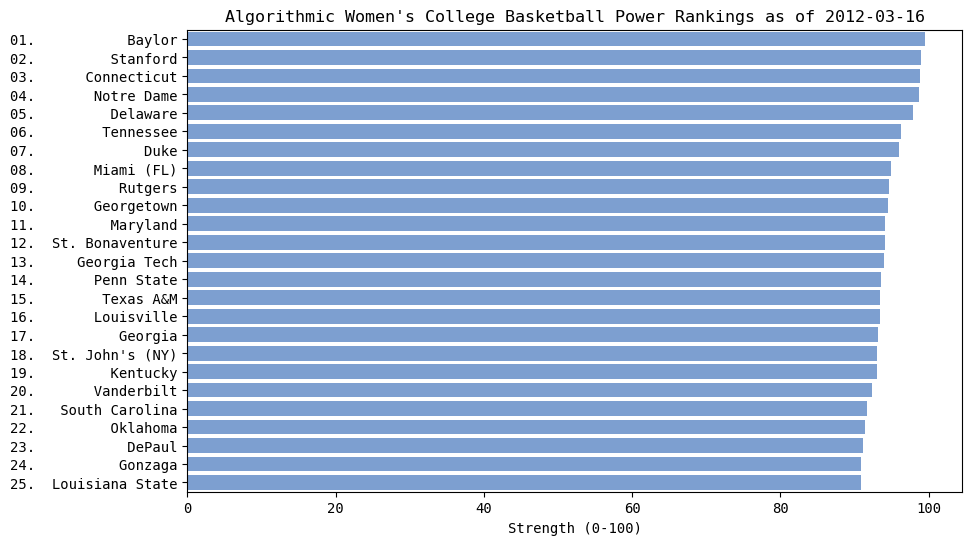

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'monospace'  # so spacing is consistent for y axis

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ratings_display.head(25)['Strength'],
    y=(
        df_ratings_display.head(25).index.map(lambda x: str(x).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ratings_display.head(25)['Team'].str.pad(max(df_ratings_display.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#6f9cde',
    dodge=False
)

plt.xlabel('Strength (0-100)')
plt.ylabel(None)
plt.title(f"Algorithmic Women's College Basketball Power Rankings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

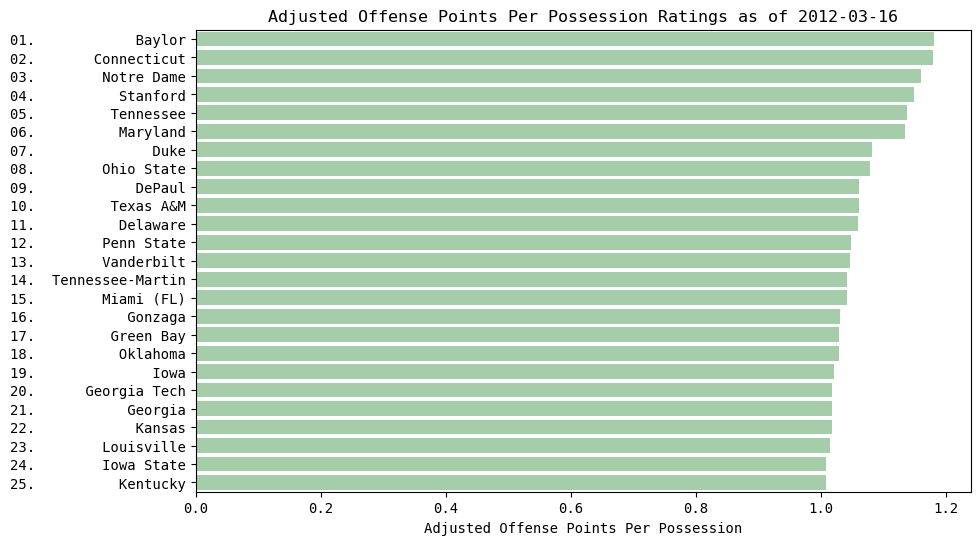

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_offense.head(25)['Rating'],
    y=(
        df_ppp_offense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_offense.head(25)['Team'].str.pad(max(df_ppp_offense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#9fd4a3',
    dodge=False
)

plt.xlabel('Adjusted Offense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Offense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

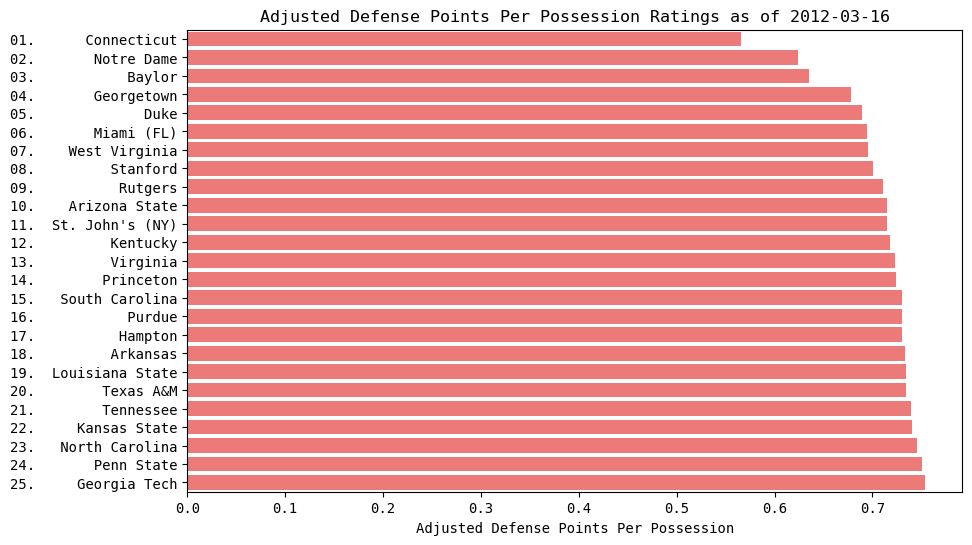

In [27]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_ppp_defense.head(25)['Rating'],
    y=(
        df_ppp_defense.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_ppp_defense.head(25)['Team'].str.pad(max(df_ppp_defense.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ff6865',
    dodge=False
)

plt.xlabel('Adjusted Defense Points Per Possession')
plt.ylabel(None)
plt.title(f"Adjusted Defense Points Per Possession Ratings as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

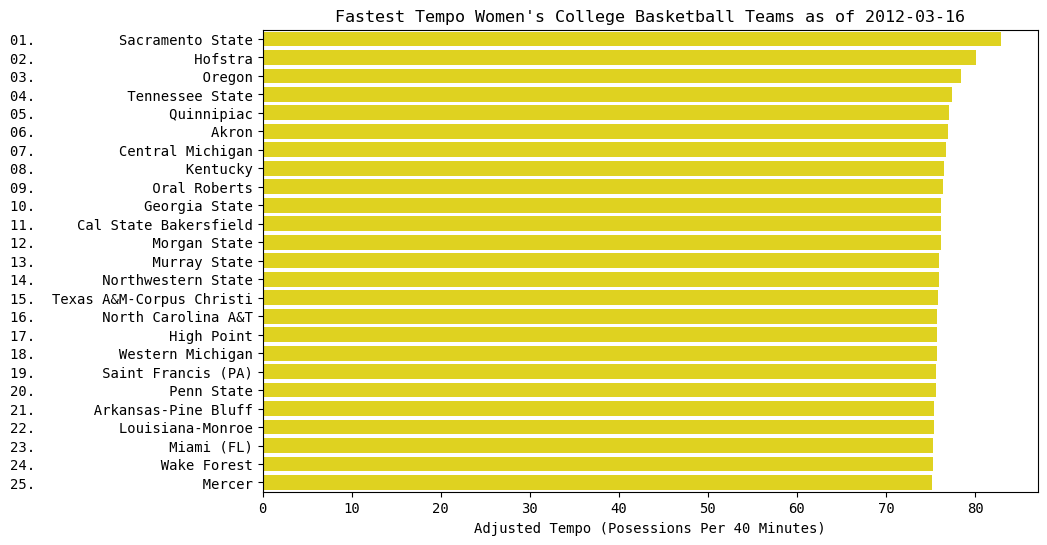

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=df_tempo.head(25)['Adjusted Tempo'],
    y=(
        df_tempo.head(25).index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_tempo.head(25)['Team'].str.pad(max(df_tempo.head(25)['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#ffee00',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Fastest Tempo Women's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

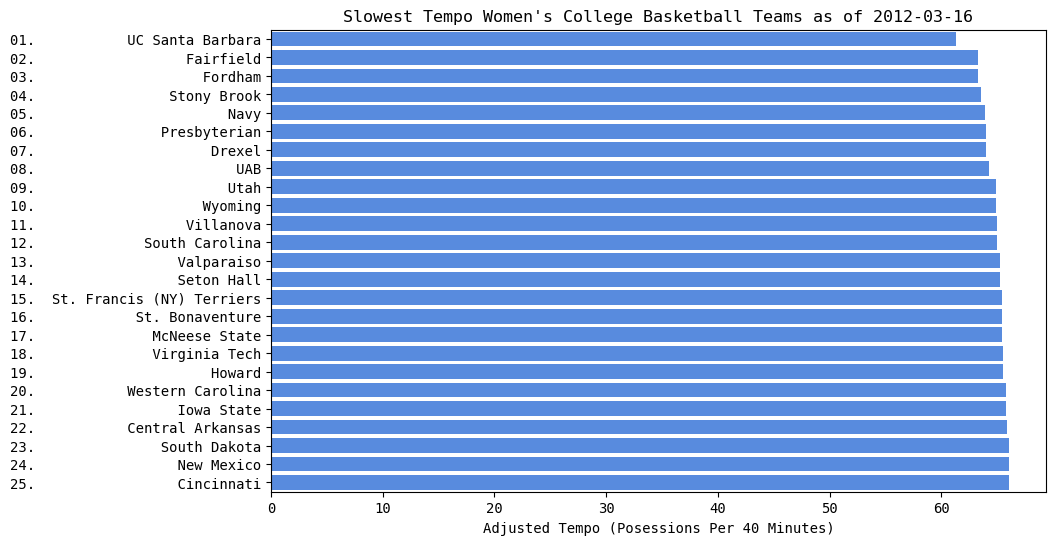

In [29]:
plt.figure(figsize=(10, 6))

df_slow = df_tempo.tail(25).iloc[::-1].reset_index(drop=True)

ax = sns.barplot(
    x=df_slow['Adjusted Tempo'],
    y=(
        df_slow.index.map(lambda x: str(x+1).zfill(2)) +  # team index with a leading 0 as needed
        '.' + ' '*2 +
        df_slow['Team'].str.pad(max(df_slow['Team'].str.len()), side='left')  # team name with padding
    ),
    color='#4285f4',
    dodge=False
)

plt.xlabel('Adjusted Tempo (Posessions Per 40 Minutes)')
plt.ylabel(None)
plt.title(f"Slowest Tempo Women's College Basketball Teams as of {df['Date'].max().strftime('%Y-%m-%d')}")

plt.show()

In [30]:
import plotly.express as px

fig = px.scatter(
    df_ppp_all,
    x='Adjusted Offense',
    y='Adjusted Defense',
    hover_data='Team',
    title=f'Adjusted Points Per Possession Ratings as of {df["Date"].max().strftime("%Y-%m-%d")}',
    width=1_000, height=600,
)

fig.update_layout(
    font_family='monospace',
    hovermode='closest',
    yaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis=dict(
        showgrid=False,
        ticks='outside',
    ),
    xaxis_range=(df_ppp_all['Adjusted Offense'].min()-0.01, df_ppp_all['Adjusted Offense'].max()+0.01),
    yaxis_range=(df_ppp_all['Adjusted Defense'].max()+0.01, df_ppp_all['Adjusted Defense'].min()-0.01),
)

fig.update_traces(marker=dict(size=12))

fig.add_vline(
    x=df_ppp_all['Adjusted Offense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

fig.add_hline(
    y=df_ppp_all['Adjusted Defense'].mean(),
    line=dict(color="red", width=2, dash="dot")
)

# sloped gridlines
minimum = min(df_ppp_all['Adjusted Offense'].min(), df_ppp_all['Adjusted Defense'].min())-0.01
maximum = max(df_ppp_all['Adjusted Offense'].max(), df_ppp_all['Adjusted Defense'].max())+0.01

for offset in np.linspace(0, maximum-minimum, 6):
    fig.add_scatter(
        x=(minimum+offset, maximum+offset),
        y=(minimum, maximum),
        mode='lines',
        line_color='grey',
        opacity=0.25,
        showlegend=False,
        hoverinfo='skip'
    )

    if offset:
        fig.add_scatter(
            x=(minimum-offset, maximum-offset),
            y=(minimum, maximum),
            mode='lines',
            line_color='grey',
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        )

fig.show()

### Miscellaneous

##### Save Rankings

In [31]:
df_sheet = pd.merge(
    df_ratings_display, df_ppp_all,
    how='left',
    on=['Team']
)

df_sheet = pd.merge(
    df_sheet, df_tempo,
    how='left',
    on=['Team']
)

df_sheet.insert(
    df_sheet.columns.get_loc('Adjusted Offense'),
    'Efficiency Margin',
    df_sheet['Adjusted Offense'] - df_sheet['Adjusted Defense']
)

df_sheet

,Team,Rating,Strength,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo
0,Baylor,5.386146,99.544129,0.545160,1.179988,0.634828,71.499272
1,Stanford,4.561610,98.966274,0.448443,1.148626,0.700183,69.596675
2,Connecticut,4.445923,98.840963,0.612579,1.178134,0.565556,69.690102
3,Notre Dame,4.369786,98.750417,0.536784,1.160459,0.623675,73.581011
4,Delaware,3.802397,97.816998,0.287090,1.059115,0.772024,67.789724
...,...,...,...,...,...,...,...
337,Jacksonville State,-3.028280,4.616452,-0.306899,0.713291,1.020190,72.594796
338,Wagner,-3.098305,4.317722,-0.248973,0.734448,0.983421,71.687497
339,Arkansas-Pine Bluff,-3.398379,3.234617,-0.355759,0.659395,1.015154,75.370280
340,North Carolina Central,-3.524660,2.861865,-0.360631,0.656186,1.016817,72.756569


In [32]:
df_sheet.to_parquet(f'../data/preprocessed/womens_my_rankings/my_rankings_{season}.parquet')

'Done'

'Done'